In [156]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [157]:
load_dotenv()

True

In [158]:
class State(TypedDict):
    ques: str
    ans: str

In [159]:
model = ChatGroq(
    model='openai/gpt-oss-20b'
)

In [160]:
def qa(state: State) -> State:
    question = state['ques']

    prompt = f'Answer the following question {question}'

    answer = model.invoke(prompt).content

    state['ans'] = answer

    return state

In [161]:
graph = StateGraph(State)

graph.add_node('Question_Answer', qa)

graph.add_edge(START, 'Question_Answer')
graph.add_edge('Question_Answer', END)

In [162]:
workflow = graph.compile()

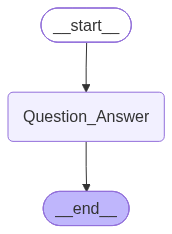

In [163]:
workflow

In [164]:
initial_state = {
    'ques': 'How far is moon from earth'
}

final_state = workflow.invoke(initial_state)
final_state

{'ques': 'How far is moon from earth',
 'ans': 'The Moon is about **384\u202f400\u202fkm** from Earth on average.  \nIts distance varies between roughly **363\u202f300\u202fkm** at perigee (closest) and **405\u202f500\u202fkm** at apogee (farthest).'}